# Exercise 2

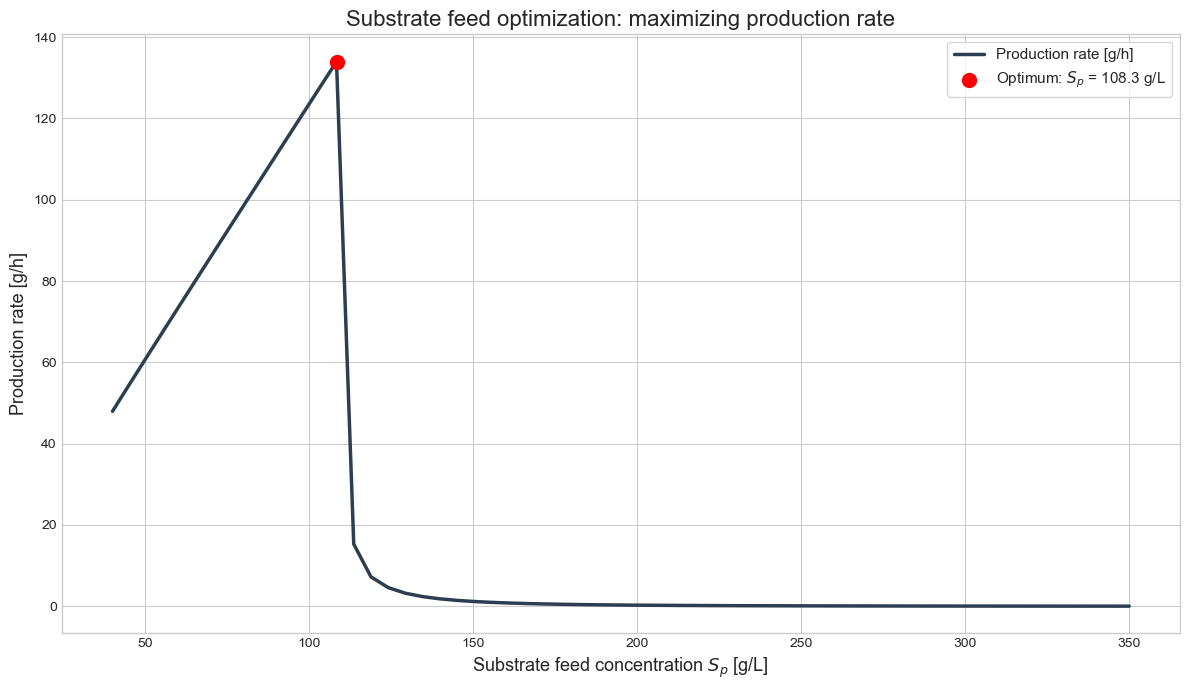

Optimization results:
Sp Optimum : 108.31 g/L
Production rate max : 133.9660 g/h


In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Params
mu_max = 0.3 # per hour
K_S = 0.8 # g glucose / L
K_I = 100 # g glucose / L
Y_XS = 0.45 # g cells / g glucose
Y_XP = 0.15 # g cells / g product

S0_feed = 80 # g glucose / L (initiation feed)
SP_feed = 80 # g glucose / L (processing feed)

FI = 0.2 # L/h (initiation)
FP = 0.5 # L/h (processing)
FH = 2.5 # L/h (harvesting)

# Phase Durations (Processing Times)
dt_I = 1 # h duration of initiation
dt_P = 5 # h duration of processing (6-1)
dt_H = 1 # h duration of harvesting (7-6)
cycle_time = dt_P + dt_H

# Kinetics Harvest
def mu_net(S):
    """Uncompetitive substrate inhibition Haldane model"""
    mu_net = mu_max * S / (K_S + (S + S**2 / K_I))
    return mu_net


def odes_initiation(t, y):
    N_X, N_S, N_P, V = y
    X = N_X / V
    S = N_S / V
    mu = mu_net(S)
    dNX = mu * X * V
    dNS = FI * S0_feed - (mu * X * V / Y_XS)
    dNP = (mu * X * V / Y_XP)
    dV  = FI
    return [dNX, dNS, dNP, dV]

def odes_processing(t, y, Sp):
    N_X, N_S, N_P, V = y
    X = N_X / V
    S = N_S / V
    mu = mu_net(S)
    dNX = mu * X * V
    dNS = FP * Sp - (mu * X * V / Y_XS)
    dNP = (mu * X * V / Y_XP)
    dV  = FP
    return [dNX, dNS, dNP, dV]

def odes_harvesting(t, y):
    N_X, N_S, N_P, V = y
    X = N_X / V
    S = N_S / V
    P = N_P / V

    mu = mu_net(S)
    dNX = -FH * X + mu * X * V
    dNS = -FH * S - (mu * X * V / Y_XS)
    dNP = -FH * P + (mu * X * V / Y_XP)
    dV = -FH
    return [dNX, dNS, dNP, dV]

def calculate_performance(target_Sp):
    V0  = 0.85 # L
    X0 = 30 # g/L
    N_X0 = X0 * V0 # g
    S0 = 0 # g/L
    P0 = 0 # g/L
    y = [N_X0, S0, P0, V0]
    sol_i = solve_ivp(odes_initiation, [0, 1], y, method='BDF')
    y = sol_i.y[:, -1]
    
    for _ in range(10):
        sol_p = solve_ivp(odes_processing, [0, 5], y, method='BDF', args=(target_Sp,))
        y = sol_p.y[:, -1]
        mass_P_before = y[2]
        sol_h = solve_ivp(odes_harvesting, [0, 1], y, method='BDF')
        y = sol_h.y[:, -1]
        mass_P_harvested = mass_P_before - y[2]
    
    return mass_P_harvested / cycle_time

#60 points
sp_test = np.linspace(40, 350, 60)
rates = [calculate_performance(s) for s in sp_test]

idx_max = np.argmax(rates)
best_sp = sp_test[idx_max]
max_rate = rates[idx_max]

plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(sp_test, rates, color='#2c3e50', linewidth=2.5,
         label='Production rate [g/h]')
plt.scatter(best_sp, max_rate, color="#ff0000", s=100, zorder=5,
            label=f'Optimum: $S_p$ = {best_sp:.1f} g/L')

plt.title('Substrate feed optimization: maximizing production rate', fontsize=16)
plt.xlabel('Substrate feed concentration $S_p$ [g/L]', fontsize=13)
plt.ylabel('Production rate [g/h]', fontsize=13)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()
#Numerical value

print(f"Optimization results:")

print(f"Sp Optimum : {best_sp:.2f} g/L")
print(f"Production rate max : {max_rate:.4f} g/h")
